## A/B Testing Analysis of Web Design Using Chi-Square Test

This project analyzes the effectiveness of two different web design versions (Group A and Group B) using an A/B testing framework. The goal of the experiment is to determine whether the new design improves user conversion rates compared to the existing version.

The dataset contains user interaction information including experimental group assignment, device type, page views, time spent on the website, and conversion outcomes. Exploratory Data Analysis (EDA) was first conducted to understand the distribution of categorical and numerical variables, identify patterns, and evaluate user engagement metrics.

To assess whether the difference in conversion rates between the two groups is statistically significant, a Chi-Square test of independence was applied. A contingency table was created to compare conversion outcomes across the experimental groups. The Chi-Square statistic and p-value were calculated to test the null hypothesis that conversion is independent of the group assignment.

In [ ]:
# !pip install numpy,pandas,seaborn,matplotlib,stats statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 11.1 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]


In [3]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import statsmodels.api as sm

In [44]:
import warnings

warnings.filterwarnings('ignore')

In [24]:
# Import data
df = pd.read_csv('ab_testing WEB.csv')
df = pd.DataFrame(df)
df.head()

,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
0,14292,B,3,424,No,Mobile,Northern Ireland
1,11682,A,9,342,No,Mobile,Scotland
2,19825,A,2,396,No,Desktop,Northern Ireland
3,16080,B,4,318,No,Desktop,Wales
4,18851,A,1,338,Yes,Desktop,Scotland


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   User ID     5000 non-null   int64 
 1   Group       5000 non-null   object
 2   Page Views  5000 non-null   int64 
 3   Time Spent  5000 non-null   int64 
 4   Conversion  5000 non-null   object
 5   Device      5000 non-null   object
 6   Location    5000 non-null   object
dtypes: int64(3), object(4)
memory usage: 273.6+ KB


In [26]:
df.describe()

,User ID,Page Views,Time Spent
count,5000.000000,5000.000000,5000.000000
mean,14925.159000,7.537600,242.512600
std,2869.153773,4.022465,118.254153
min,10001.000000,1.000000,40.000000
25%,12456.250000,4.000000,137.000000
50%,14858.500000,8.000000,243.000000
75%,17379.750000,11.000000,346.000000
max,19995.000000,14.000000,449.000000


### Data Cleaning

In [27]:
df = df.drop(columns='User ID', axis=1)

In [28]:
df.isna().sum()

Group         0
Page Views    0
Time Spent    0
Conversion    0
Device        0
Location      0
dtype: int64

In [29]:
df.duplicated().sum()

128

In [30]:
df = df.drop_duplicates()

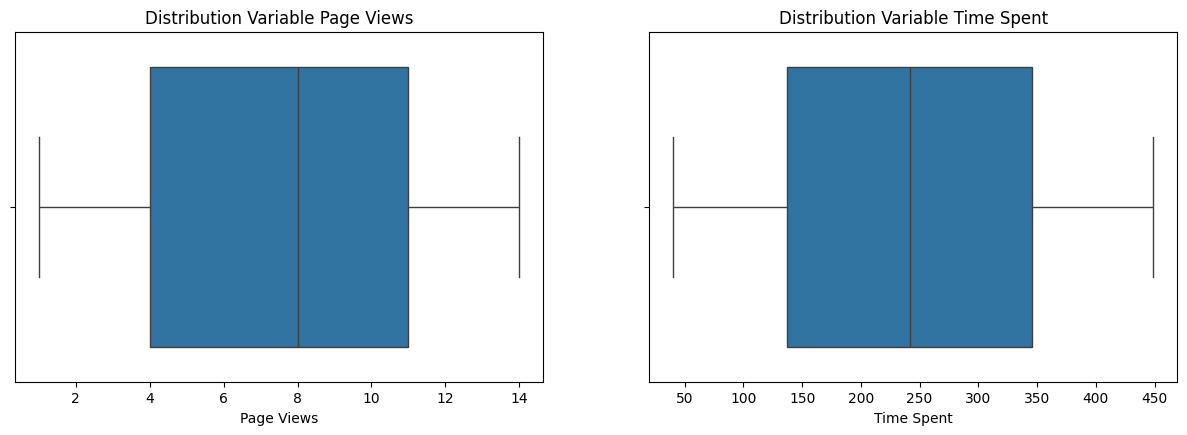

In [79]:
numeric = df.select_dtypes(exclude='object').columns

plt.figure(figsize=(15,10))

for i, col in enumerate(numeric,1):
    plt.subplot(len(numeric),2,i)
    sns.boxplot(data=df, x=df[col])
    plt.title(f'Distribution Variable {col}')

plt.show()

### EDA

In [33]:
df.describe()

,Page Views,Time Spent
count,4872.000000,4872.000000
mean,7.535099,242.175493
std,4.024407,118.370751
min,1.000000,40.000000
25%,4.000000,137.000000
50%,8.000000,242.000000
75%,11.000000,346.000000
max,14.000000,449.000000


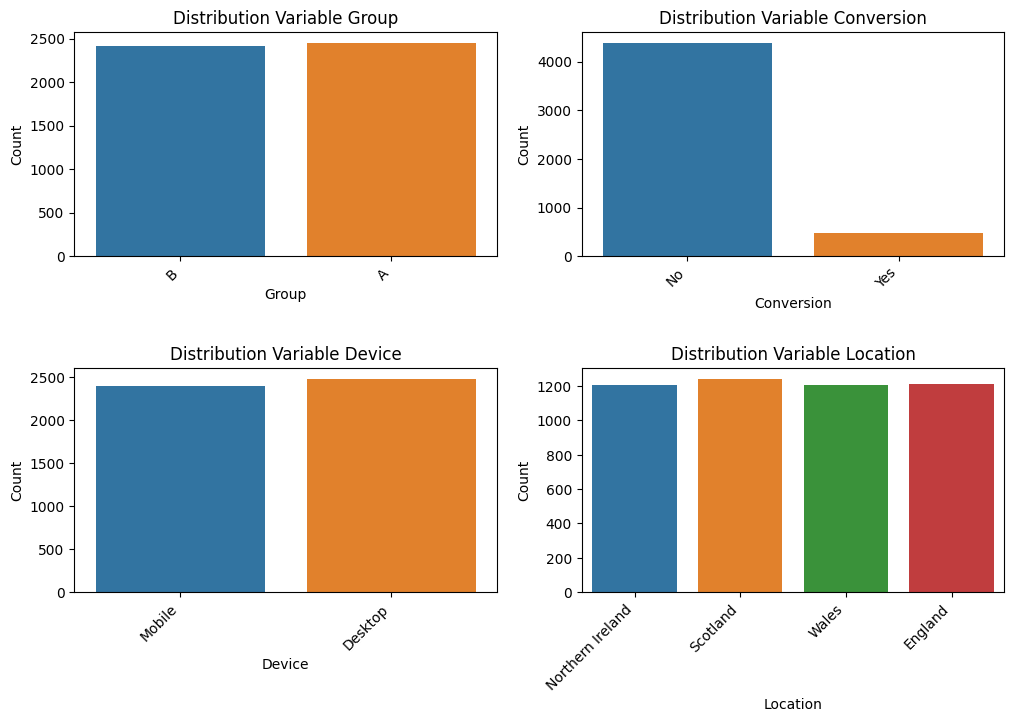

In [ ]:
categoric = df.select_dtypes(include='object').columns

plt.figure(figsize=(12,16))

for i, col in enumerate(categoric, 1):
    plt.subplot(len(categoric), 2, i)
    
    ax = sns.countplot(data=df, x=col, hue=col, palette="tab10")
    
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Distribution Variable {col}')
    plt.xlabel(col)
    plt.ylabel("Count")
    
plt.subplots_adjust(hspace=0.5)
plt.show()

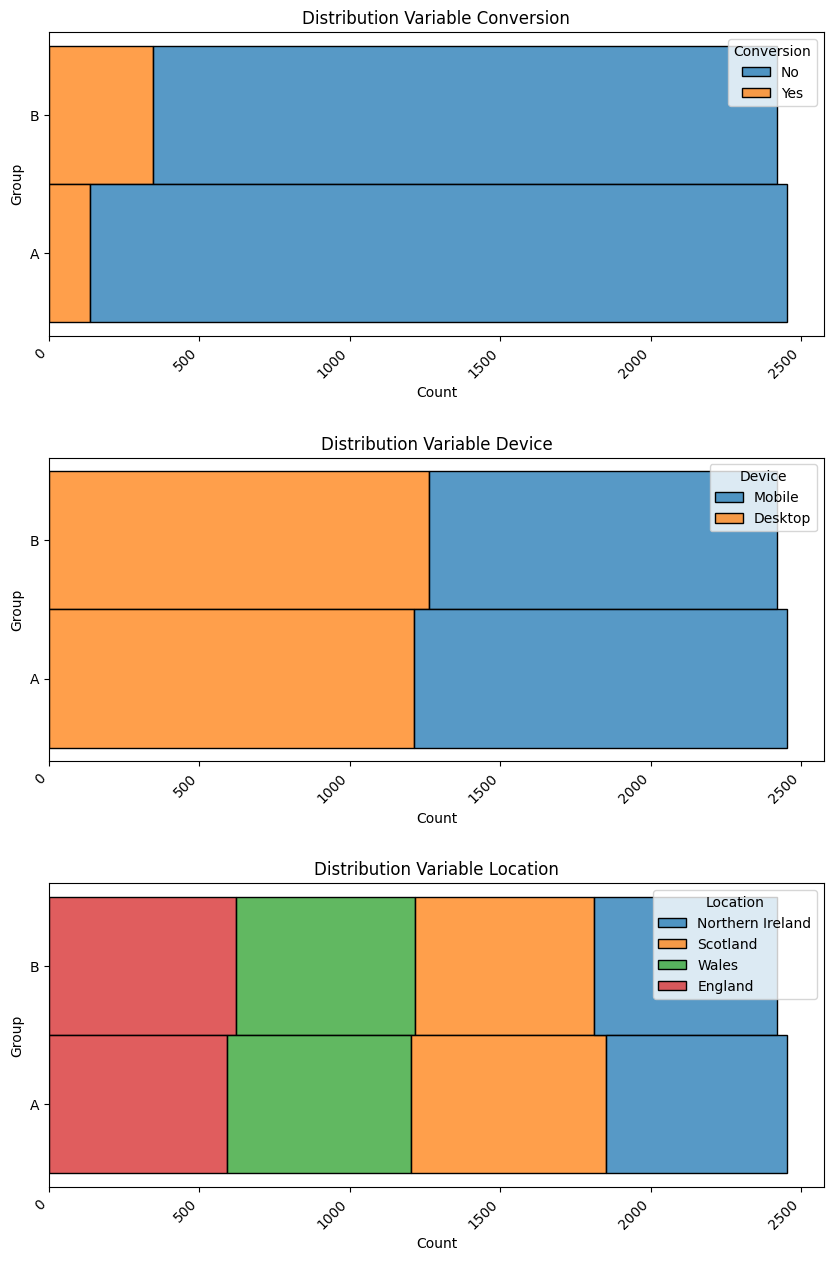

In [48]:
var = df.select_dtypes(exclude='int').columns.difference(['Group'])

plt.figure(figsize=(10,15))

for i, col in enumerate(var, 1):
    plt.subplot(len(var), 1, i)
    sns.histplot(data=df, y='Group',hue=col, multiple="stack")
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Distribution Variable {col}')

plt.subplots_adjust(hspace=0.4)
plt.show()

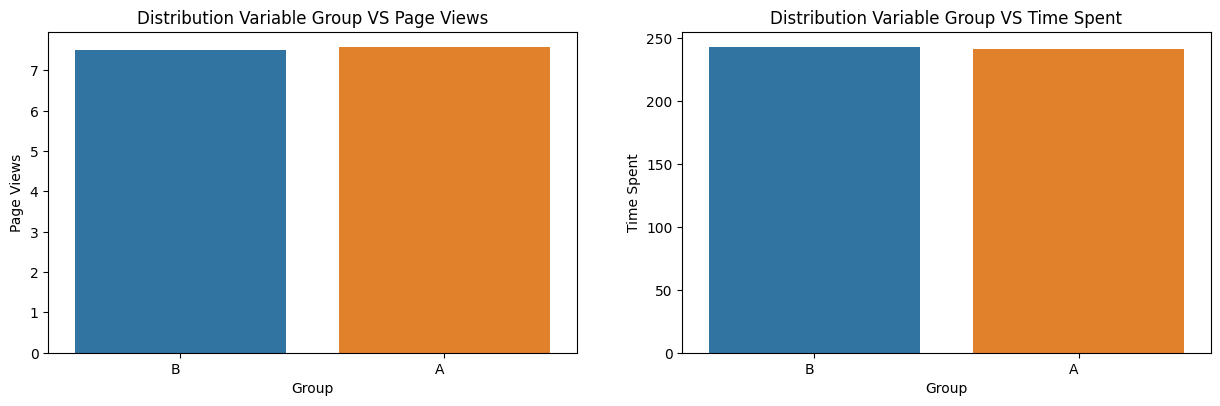

In [ ]:
var_2 = df.select_dtypes(include='int').columns.difference(['Group'])

plt.figure(figsize=(15,10))

for i, col in enumerate(var_2, 1):
    plt.subplot(len(var_2), 2, i)
    sns.barplot(data=df, x='Group', y=col,palette="tab10", estimator='mean', errorbar=None)
    plt.xticks(ha='right')
    plt.title(f'Distribution Variable Group VS {col}')

plt.subplots_adjust(hspace=0.4)
plt.show()

We have a balance dataset between group A and group B

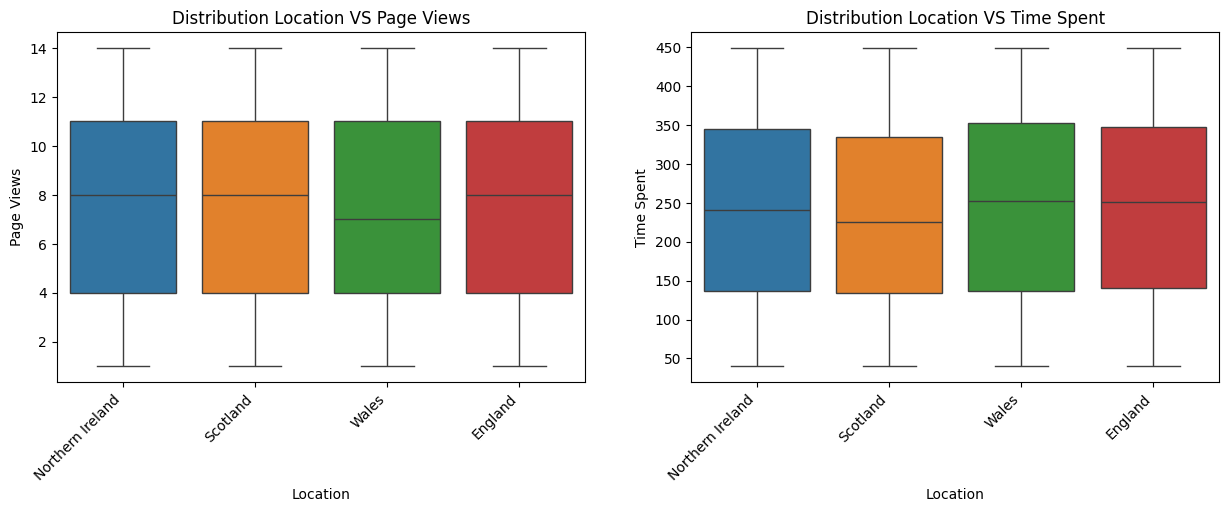

In [53]:
plt.figure(figsize=(15,10))

for i, col in enumerate(var_2, 1):
    plt.subplot(len(var_2), 2, i)
    sns.boxplot(data=df, x='Location', y=col,palette='tab10')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Distribution Location VS {col}')

plt.show()

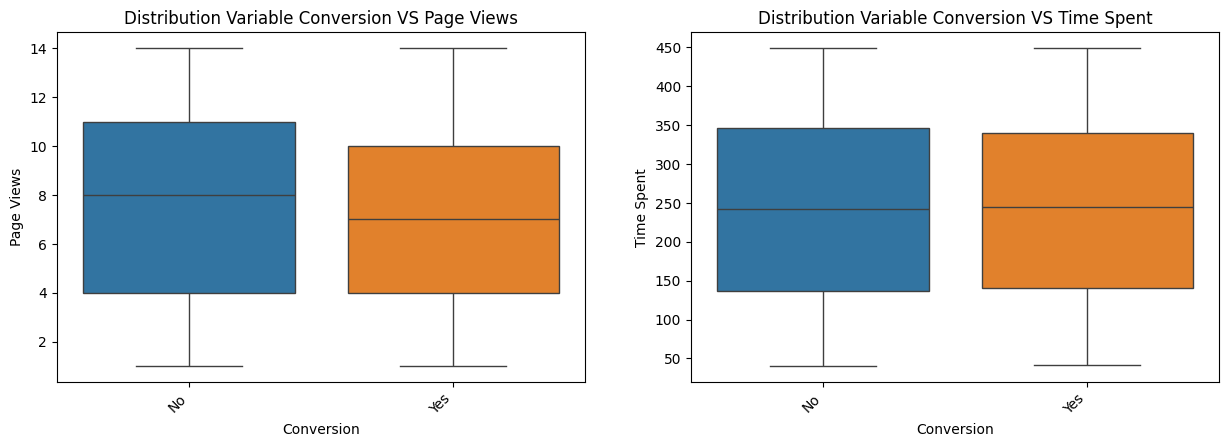

In [55]:
plt.figure(figsize=(15,10))

for i, col in enumerate(var_2, 1):
    plt.subplot(len(var_2), 2, i)
    sns.boxplot(data=df, x='Conversion', y=col,palette='tab10')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Distribution Variable Conversion VS {col}')

plt.show()

We can see there is no outlier and dataset is balance to be testing

In [63]:
df.groupby(['Group','Device'])['Conversion'].value_counts().unstack()

Conversion       No  Yes
Group Device            
A     Desktop  1142   73
      Mobile   1175   63
B     Desktop  1085  178
      Mobile    987  169

In [61]:
metrics = ['Page Views', 'Time Spent']
group_sets = [
    ['Group','Device','Conversion'],
    ['Group','Conversion']
]

for groups in group_sets:
    for metric in metrics:
        result = df.groupby(groups)[[metric]].mean().unstack()
        print(f"\nGroups: {groups} | Metric: {metric}")
        print(result)


Groups: ['Group', 'Device', 'Conversion'] | Metric: Page Views
              Page Views          
Conversion            No       Yes
Group Device                      
A     Desktop   7.525394  7.082192
      Mobile    7.670638  7.269841
B     Desktop   7.577880  7.325843
      Mobile    7.455927  7.360947

Groups: ['Group', 'Device', 'Conversion'] | Metric: Time Spent
               Time Spent            
Conversion             No         Yes
Group Device                         
A     Desktop  241.479860  253.945205
      Mobile   241.044255  235.476190
B     Desktop  242.452535  242.483146
      Mobile   243.442756  242.650888

Groups: ['Group', 'Conversion'] | Metric: Page Views
           Page Views          
Conversion         No       Yes
Group                          
A            7.599050  7.169118
B            7.519788  7.342939

Groups: ['Group', 'Conversion'] | Metric: Time Spent
            Time Spent            
Conversion          No         Yes
Group                  

In [62]:
df.groupby(['Group','Device','Conversion'])[['Page Views','Time Spent']].mean().unstack()

Page Views            Time Spent            
Conversion            No       Yes          No         Yes
Group Device                                              
A     Desktop   7.525394  7.082192  241.479860  253.945205
      Mobile    7.670638  7.269841  241.044255  235.476190
B     Desktop   7.577880  7.325843  242.452535  242.483146
      Mobile    7.455927  7.360947  243.442756  242.650888

### A/B Testing

Because both variables (Group, Conversion) are categorical so I use chi-square and this tests whether conversion rate differs between groups.

In [64]:
df.groupby(['Group','Device'])['Conversion'].value_counts().unstack()

Conversion       No  Yes
Group Device            
A     Desktop  1142   73
      Mobile   1175   63
B     Desktop  1085  178
      Mobile    987  169

In [66]:
table = pd.crosstab(df['Group'], df['Conversion'])
chi2, p, dof, expected = chi2_contingency(table)
print(f"\nChi-Square Statistic = {chi2:.4f}")
print(f"P-Value = {p:.4f}")
print(f"Degrees of Freedom = {dof}")
print("\n Expected Frequencies:")
print(expected)


Chi-Square Statistic = 104.6370
P-Value = 0.0000
Degrees of Freedom = 1

 Expected Frequencies:
[[2209.81465517  243.18534483]
 [2179.18534483  239.81465517]]


A Chi-Square test of independence was conducted to examine the relationship between experimental group and conversion. The results showed a statistically significant association between group assignment and conversion outcome, χ²(1) = 104.64, p < 0.001. This indicates that the conversion rate differs significantly between Group A and Group B.

=> Versions A and B of the experiment produced different conversion rates and one version was significantly better.

In [ ]:
# See which group have better conversion rate
df.groupby('Group')['Conversion'].value_counts(normalize=True)

Group  Conversion
A      No            0.944558
       Yes           0.055442
B      No            0.856552
       Yes           0.143448
Name: proportion, dtype: float64

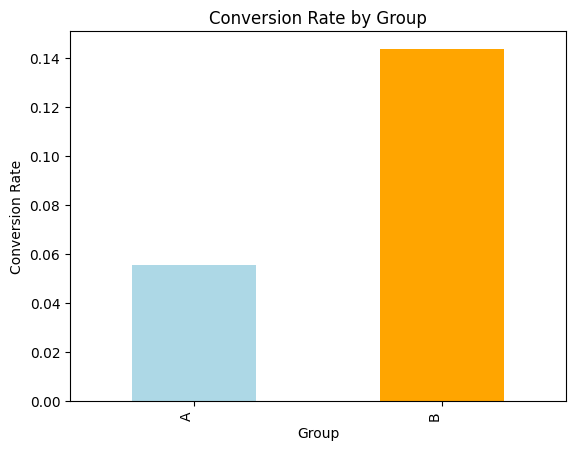

In [76]:
conversion = df.groupby('Group')['Conversion'].value_counts(normalize=True).unstack()

conversion['Yes'].plot(kind='bar',color=['lightblue','orange'])
plt.ylabel("Conversion Rate")
plt.xticks(rotation=90, ha='right')
plt.title("Conversion Rate by Group")
plt.show()

Group B has 14.34% conversion rate and performs significantly better than Group A so we should deploy B for user

## Conclussion

The A/B test results show a statistically significant difference between design A and design B. Design B achieves a higher conversion rate, indicating that the new design improves user purchase behavior. Therefore, design B is the preferred design for implementation.